# ACD example: ADHDP (`design="adhdp"`) on ImprovedB747Env

This notebook demonstrates `tensoraerospace.agent.ADP` in **ADHDP** mode.

- Critic: learns action-dependent cost-to-go \(Q(s,a)\) via TD.
- Actor: deterministic policy updated to minimize \(Q(s,\pi(s))\).

This is the *action-dependent* scalar critic family (closest to ADHDP/HDP ideas, but implemented in a practical modern TD way).



In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "tensoraerospace").exists():
            return p
    return start


# Make sure repo root + example helpers are importable
HERE = Path.cwd().resolve()
ROOT = _find_repo_root(HERE)
EX_DIR = ROOT / "example" / "dynamic-programming"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(EX_DIR))

import numpy as np
import tensoraerospace

from tensoraerospace.agent import ADP
from acd_b747_common import make_env_b747_sine, plot_rollout, rollout

print("repo root:", ROOT)
print("tensoraerospace from:", Path(tensoraerospace.__file__).resolve())



2026-01-09 16:20:50.350042: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-09 16:20:50.350074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-09 16:20:50.350904: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-09 16:20:50.356337: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 16:20:51.196162: W tensorflow/compiler/tf2

repo root: /home/mr8bit/Projects/TensorAeroSpace
tensoraerospace from: /home/mr8bit/Projects/TensorAeroSpace/tensoraerospace/__init__.py


In [2]:
# ---- User controls ----
DT = 0.1
N_STEPS = 300
REWARD_MODE = "tracking"  # "tracking" or "step_response"

# Observation
INCLUDE_REFERENCE_IN_OBS = True  # recommended for ADHDP stability

# Sine reference (pitch)
SINE_AMP_DEG = 1.0
SINE_FREQ_HZ = 0.05

# ADP/ACD
DESIGN = "adhdp"
DEVICE = "cpu"
GAMMA = 0.99
HIDDEN_SIZE = 64

# Training
TRAIN_EPISODES = 300
MAX_STEPS_PER_EPISODE = N_STEPS

# Practical stabilizers: replay + target networks
USE_REPLAY = True
REPLAY_CAPACITY = 50_000
BATCH_SIZE = 64
UPDATES_PER_STEP = 1

USE_TARGET_NETWORKS = True
TAU = 0.02

ACTOR_LR = 1e-4
CRITIC_LR = 1e-4
EXPLORATION_STD = 0.02

# Stabilization baseline (recommended for open-loop unstable plants like B747)
# NOTE: ADHDP supports only PD baseline (computed from observation) because replay breaks PID statefulness.
ADHDP_USE_BASELINE = True
BASELINE_TYPE = "pd"
BASELINE_KP = -24.6295
BASELINE_KD = -7.8179

# Actor learns residual: u = u_base + RESIDUAL_SCALE * delta
RESIDUAL_SCALE = 0.25
ACTOR_DELTA_L2 = 1e-3



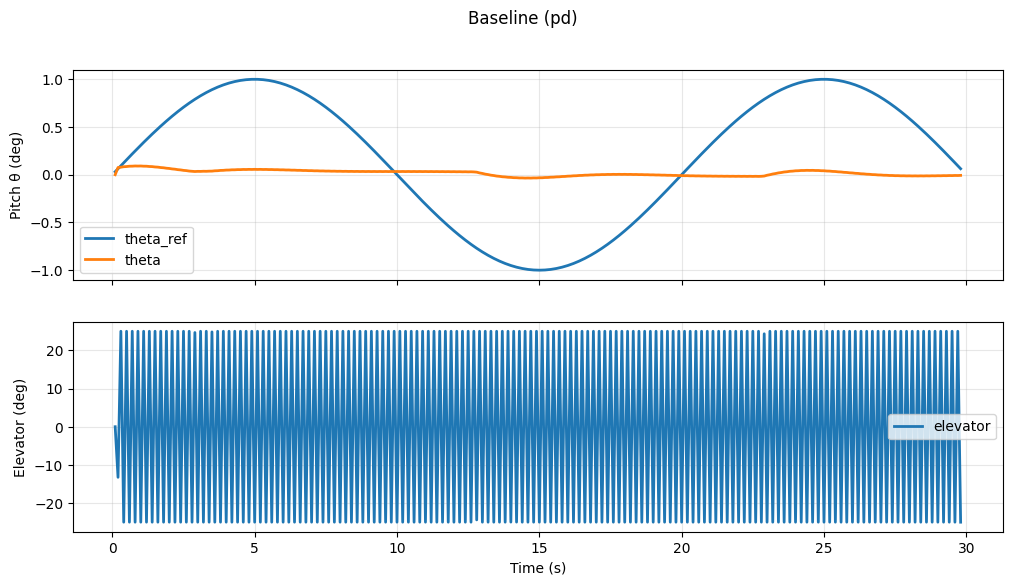

metrics: {'rmse_theta_deg': 0.6907207496467153, 'mae_theta_deg': 0.6237199344334868, 'max_abs_theta_deg': 0.9686826926593846, 'episode_return': -2.4353756088252445}
Training... episodes= 300 design= adhdp


KeyboardInterrupt: 

In [3]:
def make_env():
    return make_env_b747_sine(
        dt=DT,
        n_steps=N_STEPS,
        reward_mode=REWARD_MODE,
        sine_amp_deg=SINE_AMP_DEG,
        sine_freq_hz=SINE_FREQ_HZ,
        include_reference_in_obs=bool(INCLUDE_REFERENCE_IN_OBS),
    )

# Baseline (PD) — shows the stabilizing controller quality
base_kind = BASELINE_TYPE if bool(ADHDP_USE_BASELINE) else "random"
baseline = rollout(
    make_env(),
    agent=None,
    baseline=base_kind,
    pd_kp=BASELINE_KP,
    pd_kd=BASELINE_KD,
)
plot_rollout(baseline, title=f"Baseline ({base_kind})")

agent = ADP(
    env=make_env(),
    design=DESIGN,
    gamma=GAMMA,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    hidden_size=HIDDEN_SIZE,
    device=DEVICE,
    exploration_std=EXPLORATION_STD,
    use_replay=USE_REPLAY,
    memory_capacity=REPLAY_CAPACITY,
    batch_size=BATCH_SIZE,
    updates_per_step=UPDATES_PER_STEP,
    use_target_networks=USE_TARGET_NETWORKS,
    tau=TAU,
    log_every_updates=500,
    # baseline stabilization (actor learns residual)
    adhdp_use_baseline=bool(ADHDP_USE_BASELINE),
    dhp_baseline_type=BASELINE_TYPE,
    dhp_baseline_kp=BASELINE_KP,
    dhp_baseline_kd=BASELINE_KD,
    dhp_residual_scale=RESIDUAL_SCALE,
    dhp_actor_delta_l2=ACTOR_DELTA_L2,
)

print("Training...", "episodes=", TRAIN_EPISODES, "design=", DESIGN)
agent.train(num_episodes=int(TRAIN_EPISODES), max_steps=int(MAX_STEPS_PER_EPISODE))

trained = rollout(make_env(), agent=agent, deterministic=True)
plot_rollout(trained, title=f"Trained ({DESIGN})")

